In [ ]:
problem statement/ task: Implement machine learning (Linear regression ) on Boston_housing 
                        and predict house price (historical data) 

domain: Housing

In [ ]:
1.import Necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


2. Load boston housing data file and store in data frame df.

In [2]:
df=pd.read_csv('Boston_housing.xls')

In [5]:
#3.displat the data frame 
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,Unnamed: 14
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0,NaN
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6,NaN
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7,NaN
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4,NaN
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2,NaN


from the historical data it is observed that
   ->target variable is labelled as MEDV(Median value): so,supervised ML algoritham can apply
   ->target variable has continuous /numerical data: so Regression algorith can apply.

4. understand the data or EDA or Feature Engineering or data pre processing 

In [11]:
#4.1 display the top 5 record
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,Unnamed: 14
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0,NaN
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6,NaN
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7,NaN
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4,NaN
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2,NaN


In [6]:
#4.2 drop the column unnamed:14 because the value contain null values
df=df.drop('Unnamed: 14',axis=1)    # axis=1 mean column wise operation
                                    # axis=0 row wise operation

In [7]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [8]:
#5.display the number od dimension
df.ndim

2

In [9]:
#5.1 display the numbers the of row & columns of data frame
df.shape

(523, 14)

In [10]:
#5.2 Display the numbers of records(entries) only
print('numbers of records:',df.shape[0])

numbers of records: 523


In [11]:
#5.3 Display the numbers of features(columns) only
print('numbers of features:',df.shape[1])

numbers of features: 14


In [12]:
# 5.6display the total sample size or data piont or data frame size
df.size

7322

In [13]:
# 5.7 Display the each column information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     523 non-null    object 
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(13), object(1)
memory usage: 57.3+ KB


In [ ]:
#5.8 convert Crim column data typefrom object to numeric

In [14]:
df['CRIM']=pd.to_numeric(df['CRIM'],errors='coerce')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 57.3 KB


In [16]:
#5.9 display the statistical measure of the numeric columns.
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [17]:
# 5.10 display the correlation measure of the dataframe
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


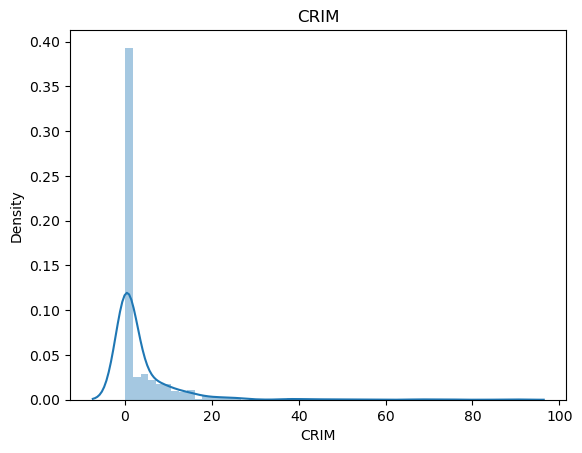

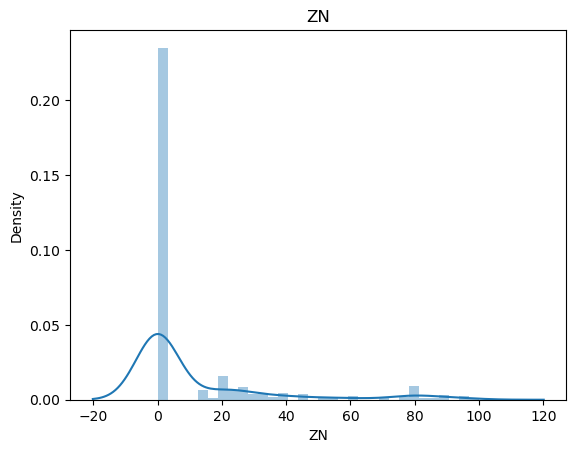

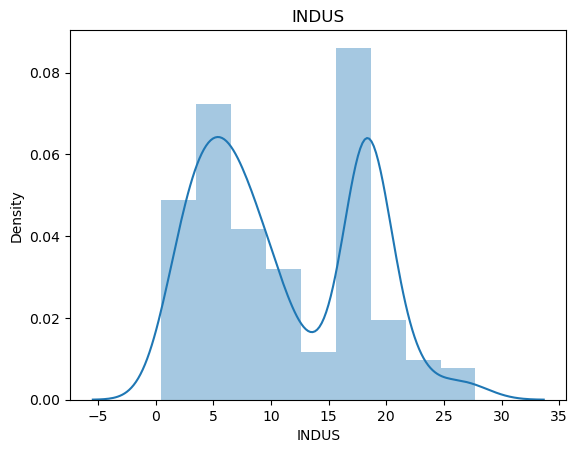

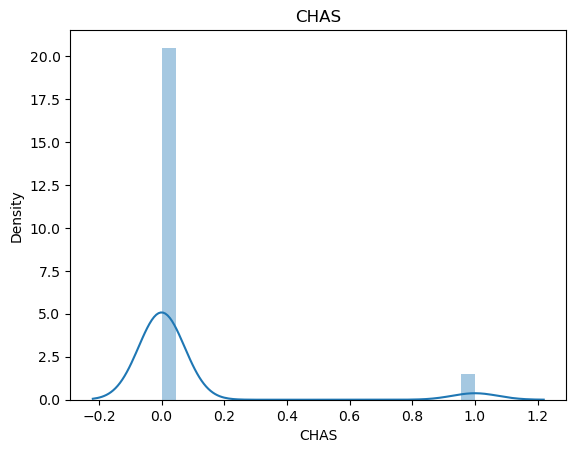

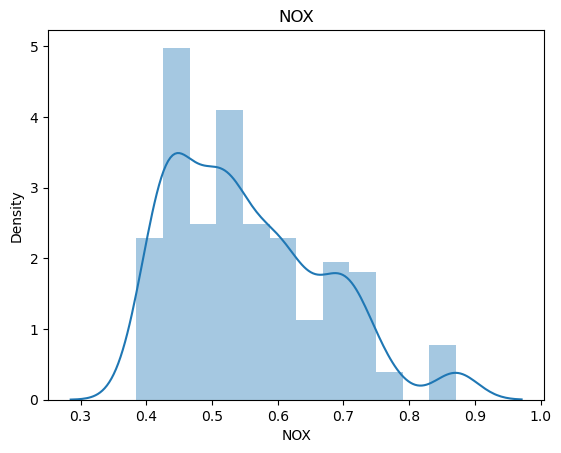

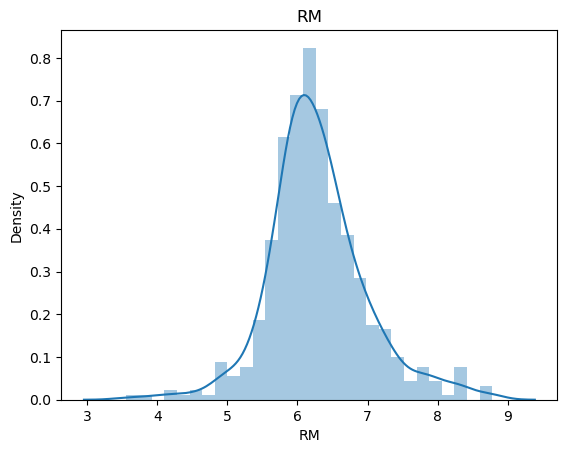

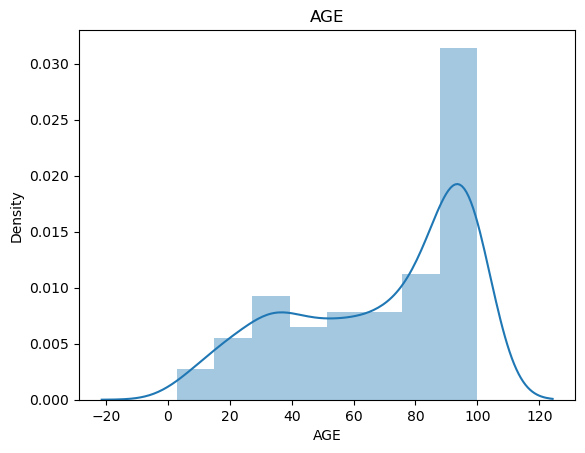

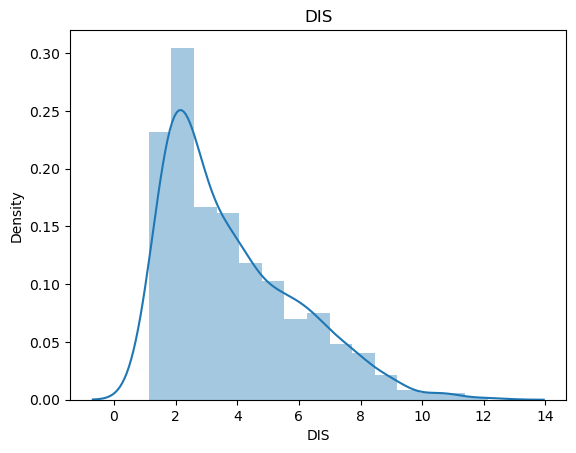

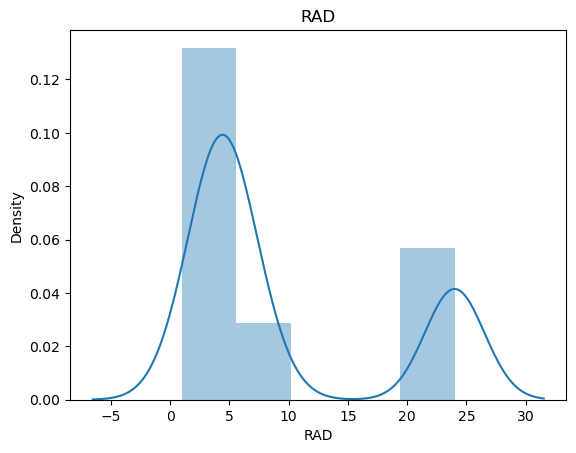

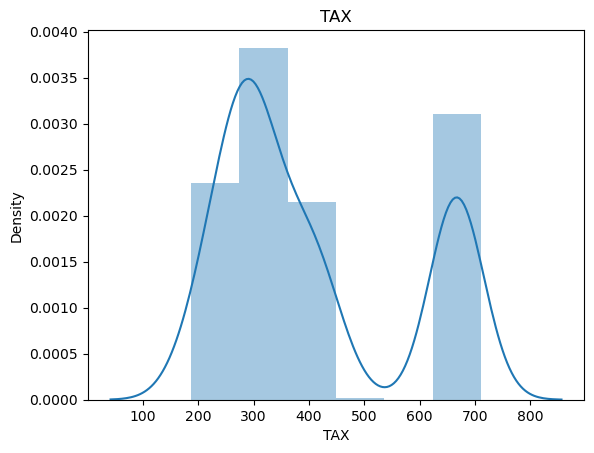

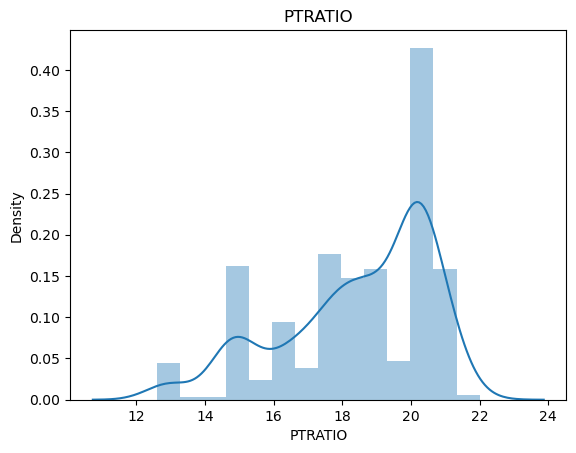

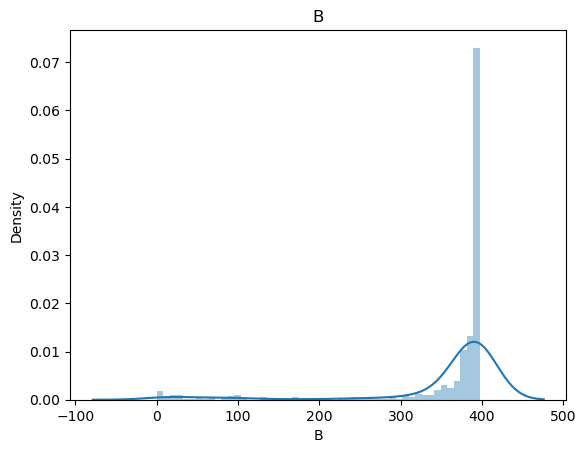

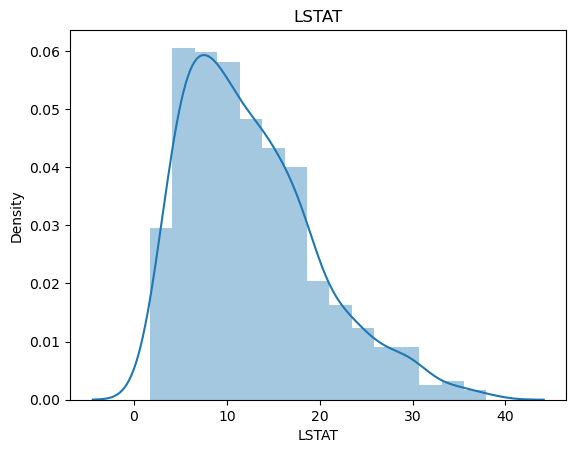

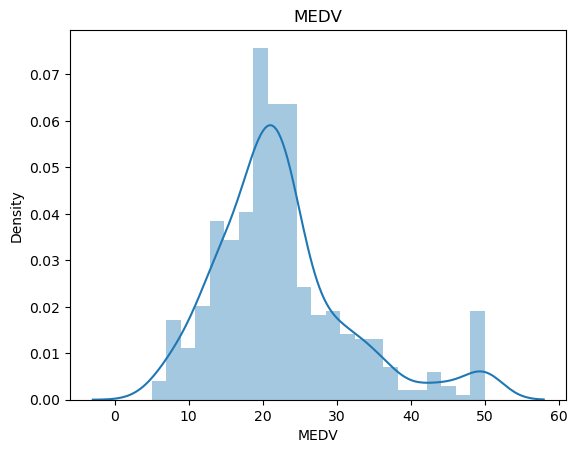

In [18]:
#5.11 display the distrubution of variables(normal distripution _bell curve)
for i in df.columns:
    if df[i].dtype!='object':
         sns.distplot(df[i])
         plt.title(i)
         plt.show()
       

In [20]:
#5.12 check the null valuesfor each columns
df.isnull().sum()
# we can use this also df.isna().sum()


#treatment of null values =1000 data piont
# there are two method
    #i) drop
    #ii)replace
#drop= if null values<=10% of data piont we caen drop it it's not a problem
#replace= we have object column we will replace by column mode
       #  we have numeric column we will replace the column mean& mwdian values
 

CRIM       17
ZN         17
INDUS      17
CHAS       17
NOX        17
RM         17
AGE        17
DIS        17
RAD        17
TAX        17
PTRATIO    17
B          17
LSTAT      17
MEDV       17
dtype: int64

In [21]:
#4.13  Replace null value
for i in df.columns:
    if df[i].dtype=='object':
        df[i]=df[i].fillna(df[i].mode()[0])
    else:
        df[i]=df[i].fillna(df[i].mean())

In [22]:
#4.14 check the null values after replace it
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

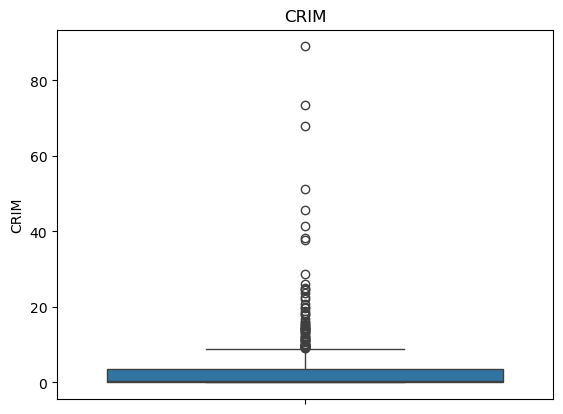

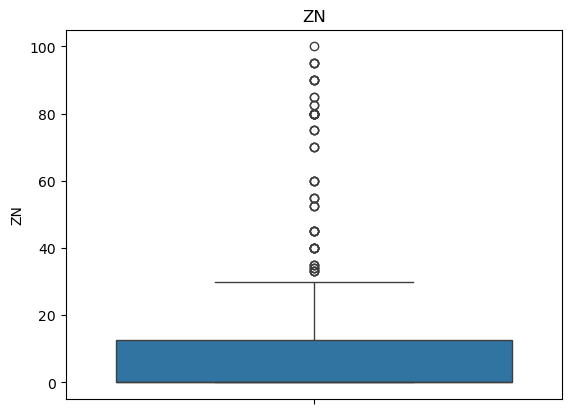

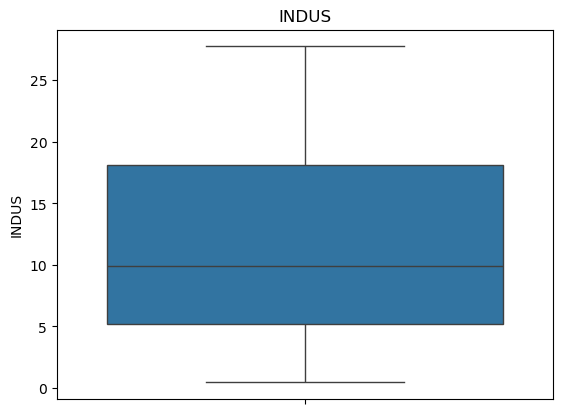

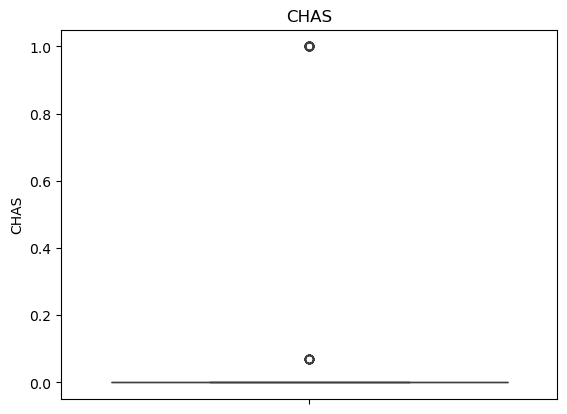

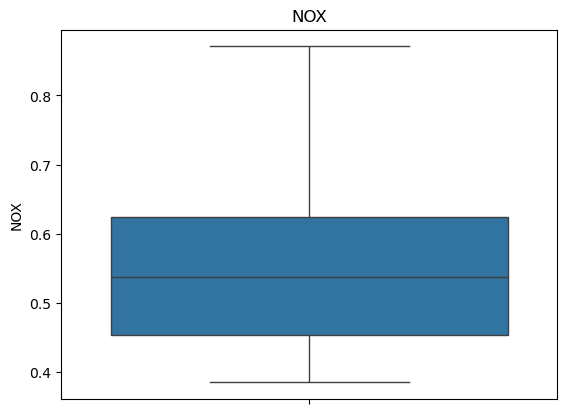

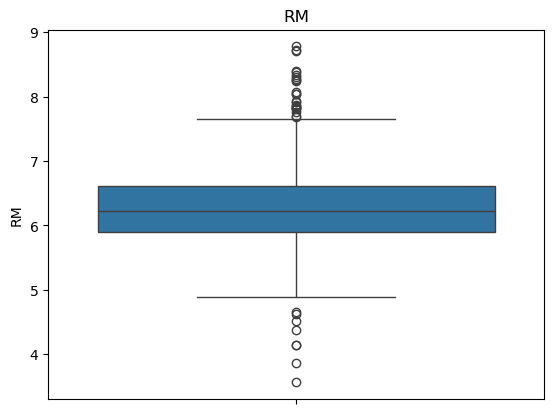

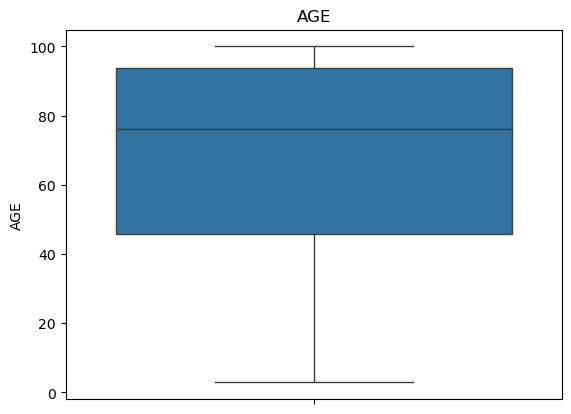

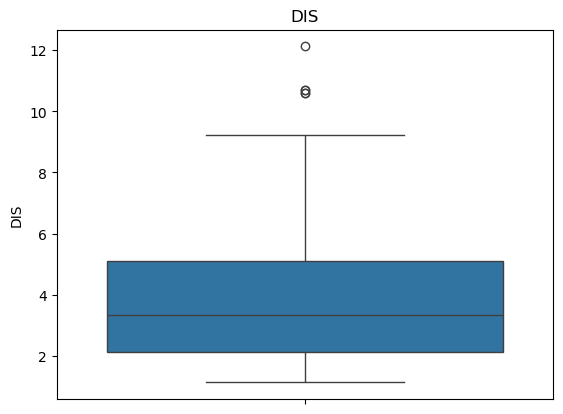

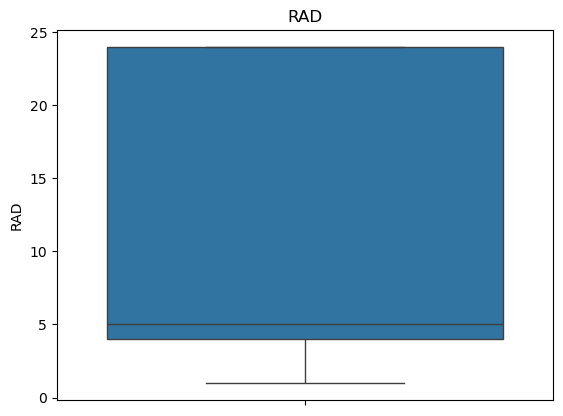

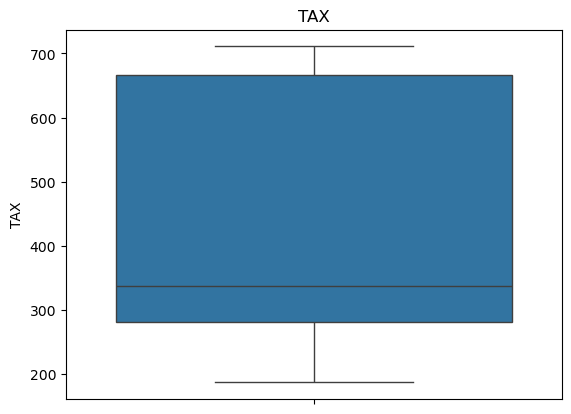

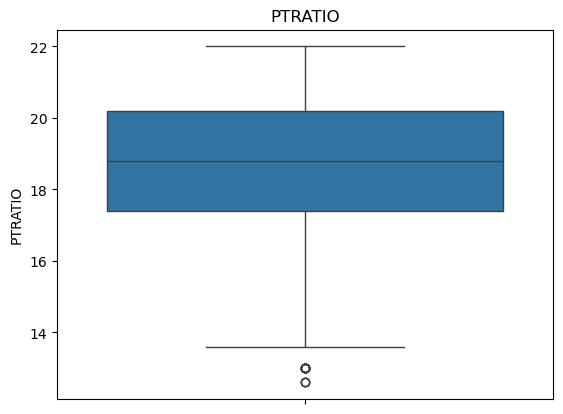

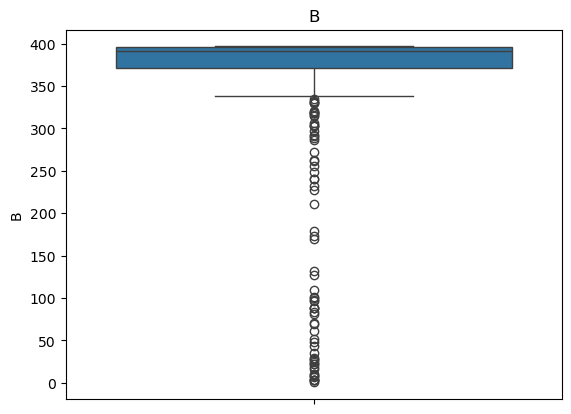

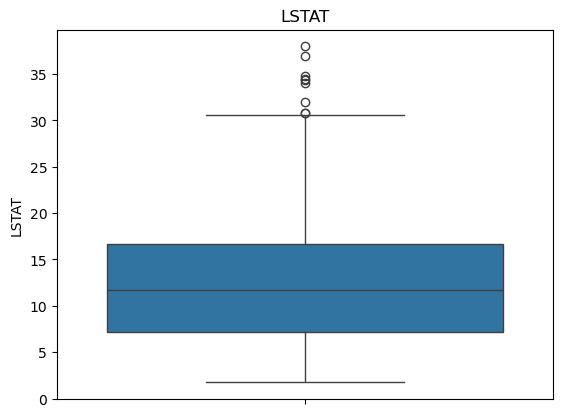

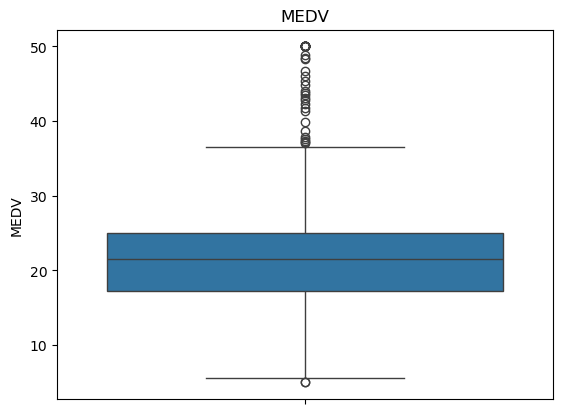

In [23]:
#5.12 check outliers (using box plot)
#outliers are verified for numeric(int/flot) columns only
for i in df.columns:
    if df[i].dtype!='object':
        sns.boxplot(df[i])
        plt.title(i)
        plt.show()

In [24]:
#5.16 remove the outliers 
out_cols=['CRIM', 'ZN', 'RM','DIS','PTRATIO', 'B', 'LSTAT', 'MEDV']
for i in out_cols:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lb=q1-1.5*iqr
    ub=q3+1.5*iqr
    df=df[(df[i]>=lb) & (df[i]<=ub)]

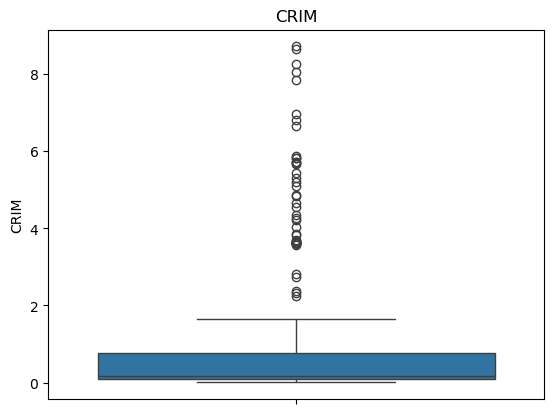

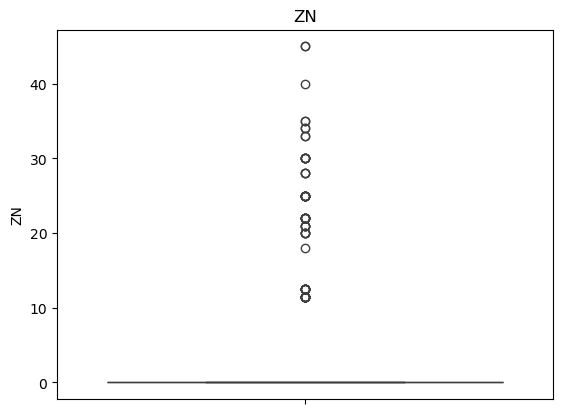

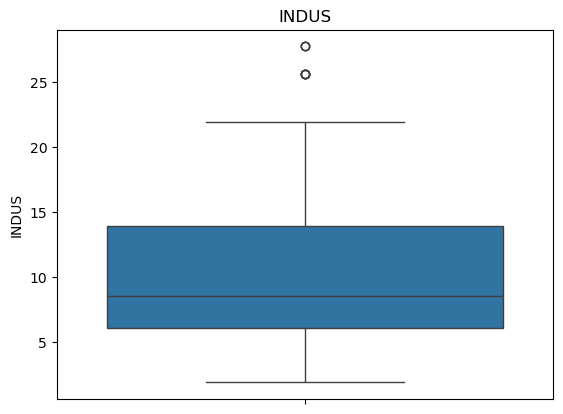

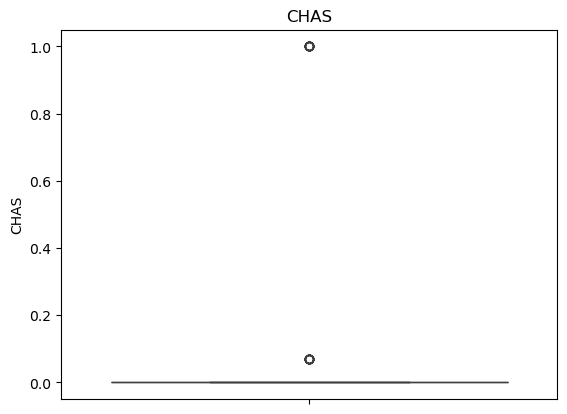

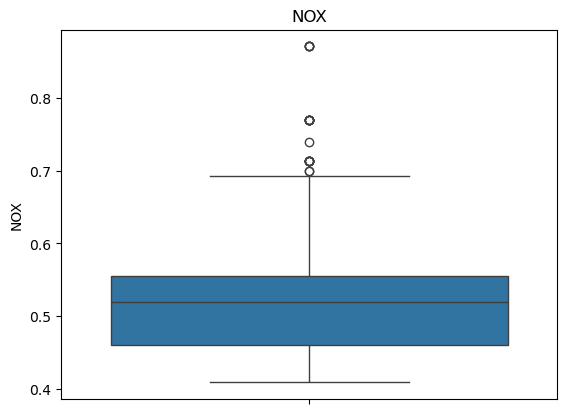

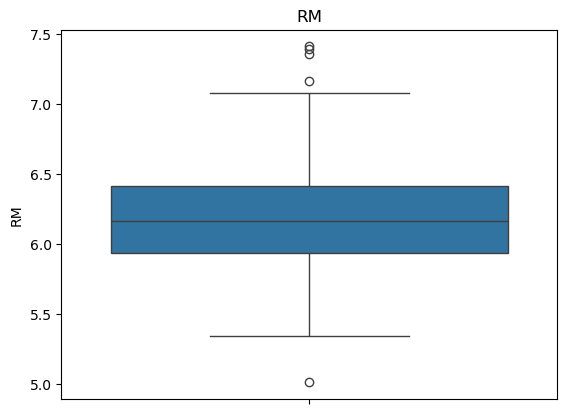

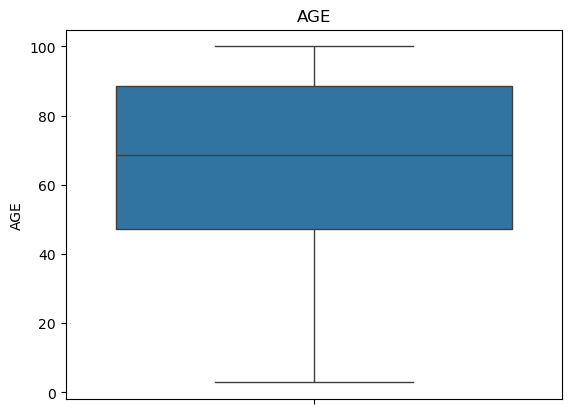

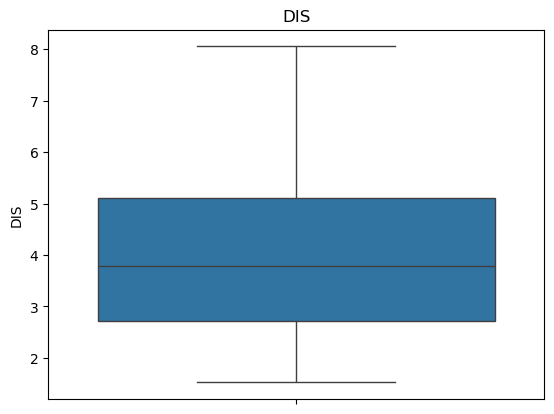

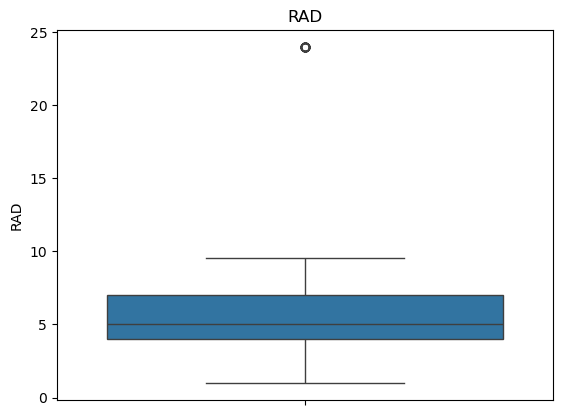

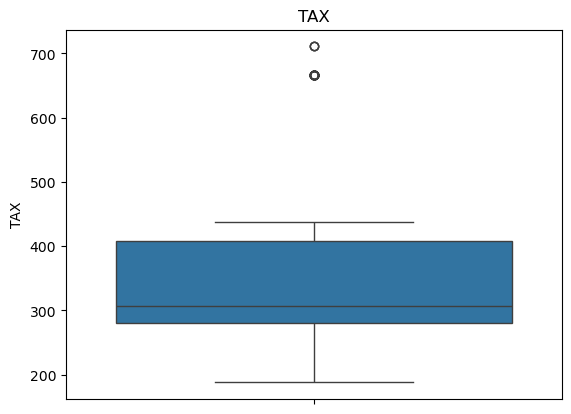

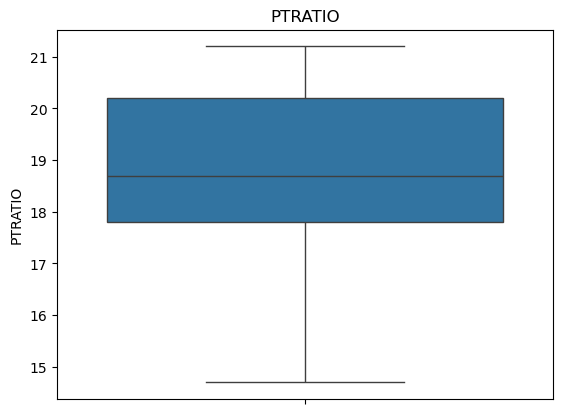

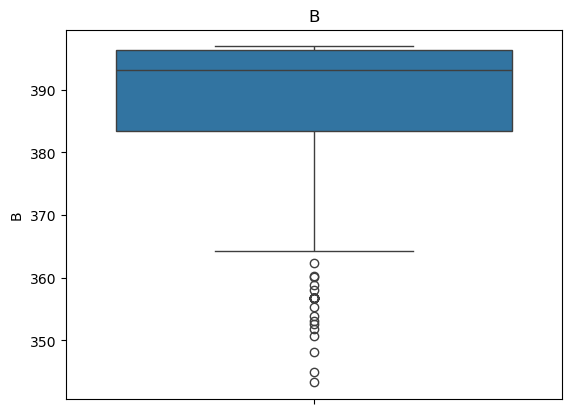

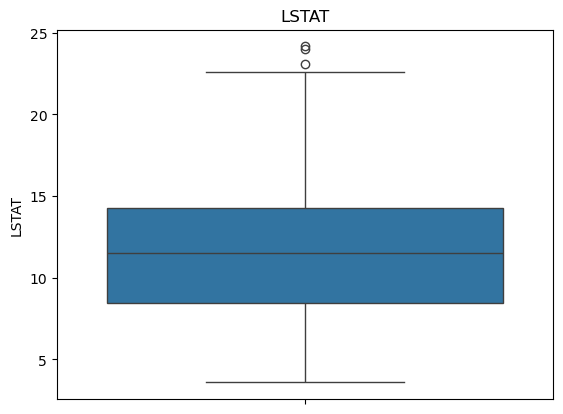

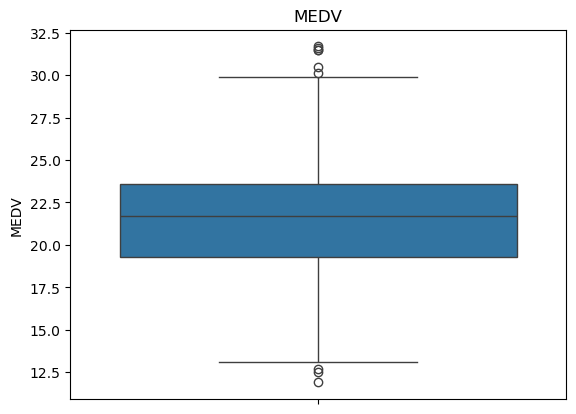

In [25]:
for i in df.columns:
    if df[i].dtype!='object':
        sns.boxplot(df[i])
        plt.title(i)
        plt.show()

In [41]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [ ]:
# 5.17 Encoding : converting object column to numeric coloums
  -> since all column of the data frame are numeric ,so encoding is required 

In [ ]:
#5.18 split or divide data frame into independent features(x)
  and dependent feature (y,target variable)

In [29]:
x=df.drop('MEDV',axis=1)
y=df['MEDV']

In [30]:
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.006320,18.000000,2.310000,0.00000,0.538000,6.575000,65.200000,4.090000,1.000000,296.000000,15.300000,396.900000,4.980000
1,0.027310,0.000000,7.070000,0.00000,0.469000,6.421000,78.900000,4.967100,2.000000,242.000000,17.800000,396.900000,9.140000
5,0.029850,0.000000,2.180000,0.00000,0.458000,6.430000,58.700000,6.062200,3.000000,222.000000,18.700000,394.120000,5.210000
6,0.088290,12.500000,7.870000,0.00000,0.524000,6.012000,66.600000,5.560500,5.000000,311.000000,15.200000,395.600000,12.430000
7,0.144550,12.500000,7.870000,0.00000,0.524000,6.172000,96.100000,5.950500,5.000000,311.000000,15.200000,396.900000,19.150000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
518,3.613524,11.363636,11.136779,0.06917,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063
519,3.613524,11.363636,11.136779,0.06917,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063
520,3.613524,11.363636,11.136779,0.06917,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063
521,3.613524,11.363636,11.136779,0.06917,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063


In [31]:
y

0      24.000000
1      21.600000
5      28.700000
6      22.900000
7      27.100000
         ...    
518    22.532806
519    22.532806
520    22.532806
521    22.532806
522    22.532806
Name: MEDV, Length: 289, dtype: float64

In [ ]:
#split x and y into train and test data
  train data size=70% of overall all data point(5125)
test data size=30% of overall all the data point(2197)

In [33]:
from sklearn.model_selection import train_test_split

In [107]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.75,random_state=48)
print('x_train_shape:',x_train.shape)
print('x_test_shape:',x_test.shape)
print('y_train_shape:',y_train.shape)
print('y_test_shape:',y_test.shape)

x_train_shape: (216, 13)
x_test_shape: (73, 13)
y_train_shape: (216,)
y_test_shape: (73,)


In [ ]:
# apply the mi model (linear regression ) on the train the data 

In [108]:
from sklearn.linear_model import LinearRegression

In [109]:
model=LinearRegression()
model.fit(x_train,y_train)    # model fitted or applied on train data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [110]:
# display model parameter regression codfficient (slope,m), regression intercept(c)
print('Regression Coefficient:',model.coef_)
print('Regression Coefficient:',model.intercept_)

Regression Coefficient: [-5.82775960e-01  5.36759608e-03  5.81278783e-03  1.06242726e+00
 -7.35226331e+00  3.94580726e+00 -3.40738015e-02 -8.43176392e-01
  3.28118266e-01 -9.06545850e-03 -5.77850814e-01 -1.40703152e-02
 -2.72667239e-01]
Regression Coefficient: 27.458901306822433


In [ ]:
# test model or predict model output by appliying testing data

In [111]:
y_pred=model.predict(x_test)

In [ ]:
# 7.display actual output and model output

In [112]:
res=pd.DataFrame()
res['actual_salary']=y_test
res['predicted_salary']=y_pred
res['error']=y_test-y_pred
res['square_of_error']=(y_test-y_pred)**2
res

,actual_salary,predicted_salary,error,square_of_error
137,17.100000,18.924057,-1.824057,3.327186
506,22.532806,21.034781,1.498026,2.244081
136,17.400000,16.582204,0.817796,0.668790
35,18.900000,21.833351,-2.933351,8.604547
296,27.100000,25.277637,1.822363,3.321006
...,...,...,...,...
79,20.300000,21.578515,-1.278515,1.634601
211,19.300000,15.936200,3.363800,11.315150
269,20.700000,22.151903,-1.451903,2.108022
49,19.400000,17.462865,1.937135,3.752493


#8. perform Evaluation of Linear Regression ML model
  i) plot the Regression Response
  ii) Quantitave measure (MSE,MAE,RMSE,F2_score)

In [113]:
p1=min(min(y_test),min(y_pred))
p2=max(max(y_test),max(y_pred))

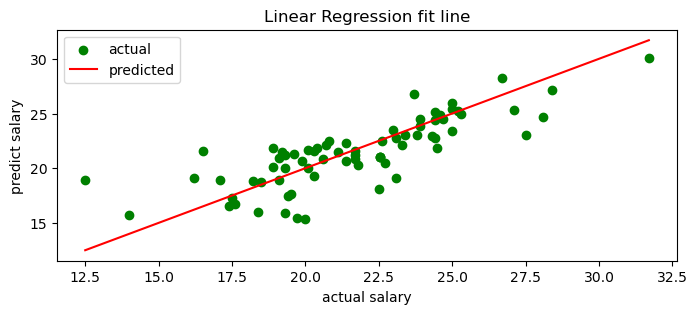

In [114]:
plt.figure(figsize=(8,3))
plt.scatter(y_test,y_pred,color='green',label='actual')
plt.plot([p1,p2],[p1,p2],color='red',label='predicted')
plt.legend()
plt.xlabel('actual salary')
plt.ylabel('predict salary')
plt.title('Linear Regression fit line')
plt.show()

In [ ]:
#8.2 quantitative measure (MSE,MAE,RMSE,R2_score)

In [115]:
from sklearn.metrics import *

In [116]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2_score=r2_score(y_test,y_pred)

In [117]:
print('mean square erroe(MSE):',mse)
print('mean absolute erroe(MAE):',mae)
print('Root mean suare erroe(RMSE):',rmse)
print('R2 score:',r2_score)

mean square erroe(MSE): 4.2180076935089135
mean absolute erroe(MAE): 1.5437415390695888
Root mean suare erroe(RMSE): 2.05377888135722
R2 score: 0.6242359012296023


In [118]:
new_sample=x_test[0:1]
pred=model.predict(new_sample)
print('predicted mean house prize:',pred)

predicted mean house prize: [18.92405743]
